

<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical Assignment 5 

    Q-Learning
<font color=green size=5>
Prepared By: 
Kooshan Fattah
 

### **Name: Arvin Baghal Asl**  
### **STD ID: 403105793**


# Homework: Q-Learning & Deep Q-Learning


In the last two lectures we moved from *planning* in a known MDP (value iteration,
policy iteration) to **reinforcement learning**: acting in an environment whose
transition function `T(s, a, s')` and reward function `R(s, a, s')` are **unknown**.
The agent must learn purely from sampled experience `(s, a, r, s')`.

In this assignment you will implement, train, and analyze two model-free RL agents:

| Part | Method | Environment | Lecture concept |
|------|--------|-------------|-----------------|
| **1** | **Tabular Q-Learning** | `FrozenLake-v1` (discrete) | Sample-based Q-value iteration, ε-greedy, off-policy |
| **2** | **Deep Q-Learning (DQN)** | `CartPole-v1` (continuous) | *Approximate* Q-learning — generalizing across states |

Part 2 is the natural continuation of the lecture's **Approximate Q-Learning**
section: when there are *"too many states to hold the Q-table in memory,"* we
replace the table with a function approximator and **generalize** across states.
In lecture this was a *linear* function of features; here we use a small
feed-forward neural network instead.

### What you will do
- Implement the ε-greedy policy and the Q-learning update from scratch.
- Write the training loops with **ε-decay** exploration.
- Run **hyperparameter experiments** (`alpha`, `gamma`, ε-decay, episodes, network size).
- Produce **visualizations** (reward curves, moving averages, Q-value heatmaps, learned policy).
- Answer **short written questions** interpreting your results.
- **Save** all key artifacts (Q-table, model weights, reward histories, plots, eval scores, policies).

### How to read the TODOs
Wherever you see a block like:
```python
# TODO: compute the TD target
```
that is a spot **you** must fill in. Each function has a docstring describing the
expected inputs/outputs. Do not change function signatures unless asked.

> **Allowed tools:** NumPy, Matplotlib, Gymnasium, PyTorch (`torch.nn`).
> **Not allowed:** any method *not* covered in the lectures — no policy gradients,
> actor-critic, PPO, prioritized/advanced replay, RNNs/transformers/residual nets.
> A plain feed-forward network, a basic uniform replay buffer, and a target network
> are the only "extras" used, and each is explained where it appears.


## 0. Setup

Run this cell first. It imports the libraries, fixes random seeds for
reproducibility, and creates the `results/` folder where every artifact is saved.

In [1]:
import os, json, random, math
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# All saved artifacts go here (created next to this notebook).
RESULTS_DIR = "results"
os.makedirs(os.path.join(RESULTS_DIR, "part1_qlearning"), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "part2_dqn"), exist_ok=True)

def moving_average(x, window=50):
    '''Simple moving average used for smoothing noisy reward curves.'''
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x.copy()
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

print("Setup complete. Gymnasium version:", gym.__version__)


Setup complete. Gymnasium version: 1.3.0


---
# Part 1 — Tabular Q-Learning on FrozenLake

## 1.1 The environment (read carefully)

`FrozenLake-v1` is a small grid world. The agent starts at the top-left tile `S`
and must reach the goal `G` at the bottom-right **without falling into a hole `H`**.

```
S F F F          S = start          (state 0)
F H F H          F = frozen, safe to walk on
F F F H          H = hole  -> episode ends, reward 0
H F F G          G = goal  -> episode ends, reward +1
```

This is a clean, fully-defined **MDP**, but remember: the *agent does not know*
`T` or `R`. It only sees `(state, action, reward, next_state)` tuples — this is
**model-free** learning.

| MDP element | In FrozenLake |
|-------------|---------------|
| **States** `s` | 16 tiles, encoded as integers `0..15` (`row*4 + col`) |
| **Actions** `a` | 4 discrete: `0=Left, 1=Down, 2=Right, 3=Up` |
| **Reward** `R` | `+1` only on reaching `G`; `0` everywhere else (a *sparse* reward) |
| **Episode** | starts at `S`, ends when reaching `G` or a hole `H` (or step limit) |
| **Discount** `γ` | future-reward weight; we pick it as a hyperparameter |
| **Transitions** `T` | deterministic if `is_slippery=False`; stochastic if `True` |

We start with `is_slippery=False` (deterministic) so improvement is easy to see,
then experiment with the slippery (stochastic) version later.

**Discounting reminder.** The agent maximizes the *discounted return*
`G_t = r_t + γ r_{t+1} + γ² r_{t+2} + ...`. With a sparse `+1` at the goal, a
`γ < 1` makes the agent prefer **shorter** paths to the goal (the `+1` is
discounted less the sooner it is reached).

In [2]:
# Deterministic FrozenLake to start (we vary is_slippery later).
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n
ACTION_NAMES = ["Left", "Down", "Right", "Up"]
# print the number of states and the number of actions
#       using `env.observation_space` and `env.action_space`.
print(f"number of states: {n_states}")
print(f"number of actions: {n_actions}")

# Show the map layout.
print("\nMap (S=start, F=frozen, H=hole, G=goal):")
for row in env.unwrapped.desc:
    print(" ".join(c.decode() for c in row))


number of states: 16
number of actions: 4

Map (S=start, F=frozen, H=hole, G=goal):
S F F F
F H F H
F F F H
H F F G


## 1.2 The ε-greedy policy

Pure exploitation (*always* take the best-known action) can get stuck and never
discover the goal. The simplest fix from lecture is **ε-greedy exploration**:

> With probability `ε` act **randomly** (explore); with probability `1 − ε` take
> the **greedy** action `argmax_a Q(s, a)` (exploit).

Implement it below.

In [3]:
def epsilon_greedy(state: int, Q: np.ndarray, epsilon: float, rng: np.random.Generator):
    '''Select an action using the epsilon-greedy policy.

    Args:
        state (int): current state index.
        Q (np.ndarray): Q-table of shape (n_states, n_actions).
        epsilon (float): probability of taking a random (exploratory) action.
        rng (np.random.Generator): random generator (use rng.random(),
            rng.integers(...)).

    Returns:
        action (int): the chosen action in [0, n_actions).
    '''
    n_actions = Q.shape[1]
    # with probability `epsilon`, return a uniformly random action.
    if rng.random() < epsilon:
        return rng.integers(n_actions)

    # otherwise (probability 1 - epsilon), return the greedy action
    #       argmax_a Q[state, a]. (np.argmax breaks ties toward the first action.)
    return np.argmax(Q[state])

    


## 1.3 The Q-learning update

This is the heart of the assignment. From lecture, Q-learning is **sample-based
Q-value iteration**. Given a single transition `(s, a, r, s')` we form a *sample
estimate* of the optimal Q-value and nudge our current estimate toward it:

$$\text{sample} = r + \gamma \max_{a'} Q(s', a')$$
$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\underbrace{r + \gamma \max_{a'} Q(s', a') - Q(s,a)}_{\text{TD error}}\big]$$

**Terminal states matter.** If `s'` is terminal there is no future, so the target
is just `r` (do **not** bootstrap `max_a' Q(s', a')`). Implement this carefully —
it is a common bug.

In [4]:
def q_learning_update(Q: np.ndarray, state, action, reward, next_state, terminated, alpha, gamma):
	'''Apply one Q-learning (off-policy TD) update, in place, and return Q.

	Args:
		Q (np.ndarray): Q-table of shape (n_states, n_actions).
		state (int): state s where the action was taken.
		action (int): action a taken.
		reward (float): reward r received.
		next_state (int): resulting state s'.
		terminated (bool): True if s' is a terminal state (goal or hole).
		alpha (float): learning rate.
		gamma (float): discount factor.

	Returns:
		Q (np.ndarray): the updated Q-table.
	'''
	# compute `best_next_q`, the value of the best action in next_state.
	#       If `terminated` is True there is NO future, so best_next_q = 0.0.
	if terminated:
		best_next_q = 0.0
	else:
		best_next_q = np.max(Q[next_state])

	# compute the TD target:  reward + gamma * best_next_q
	TD_target = reward + gamma * best_next_q

	# compute the TD error:   td_target - Q[state, action]
	TD_error = TD_target - Q[state, action]

	# update Q[state, action] by alpha * td_error
	Q[state, action] += alpha * TD_error
	return Q


## 1.4 The training loop with ε-decay

Now we put it together. Early on the agent should **explore** a lot (high ε);
as it learns it should **exploit** more (low ε). We use **exponential ε-decay**:

$$\varepsilon_t = \varepsilon_{\min} + (\varepsilon_{\max}-\varepsilon_{\min})\,e^{-\lambda t}$$

You will fill in the inner loop: pick an action, step the env, apply the update.

In [5]:
def train_q_learning(env, n_episodes=5000, alpha=0.1, gamma=0.99,
					eps_max=1.0, eps_min=0.05, eps_decay=0.001,
					max_steps=200, seed=GLOBAL_SEED, log_every=1000):
	'''Train a tabular Q-learning agent.

	Returns:
		Q (np.ndarray): learned Q-table.
		rewards_history (list[float]): total reward per episode.
		epsilon_history (list[float]): epsilon used in each episode.
	'''
	rng = np.random.default_rng(seed)
	Q = np.zeros((env.observation_space.n, env.action_space.n))
	rewards_history, epsilon_history = [], []

	for ep in range(n_episodes):
		state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
		epsilon = eps_min + (eps_max - eps_min) * math.exp(-eps_decay * ep)
		total_reward = 0.0

		for _ in range(max_steps):
			# choose `action` with epsilon_greedy(state, Q, epsilon, rng)
			action = epsilon_greedy(state, Q, epsilon, rng)

			# take the action: next_state, reward, terminated, truncated, _ = env.step(action)
			next_state, reward, terminated, truncated, _ = env.step(action)

			# update the Q-table with q_learning_update(...). Pass `terminated`
			#       (NOT terminated-or-truncated) as the terminal flag, so that a
			#       time-limit truncation does not wrongly zero the bootstrap.
			Q = q_learning_update(Q, state=state, action=action, reward=reward,
							next_state=next_state, terminated=terminated, alpha=alpha, gamma=gamma)

			# accumulate total_reward, set state = next_state
			total_reward += reward
			state = next_state

			# if terminated or truncated, break out of the step loop
			if terminated or truncated:
				break

		rewards_history.append(total_reward)
		epsilon_history.append(epsilon)
		if log_every and (ep + 1) % log_every == 0:
			recent = np.mean(rewards_history[-log_every:])
			print(f"  episode {ep+1:5d} | epsilon {epsilon:.3f} | "
				f"success rate (last {log_every}) {recent:.3f}")

	return Q, rewards_history, epsilon_history


In [6]:
# Train the agent. On deterministic FrozenLake the success rate should climb
# from ~0 toward ~1.0 as the agent discovers and locks in the optimal path.
Q_table, rewards_hist, eps_hist = train_q_learning(
    env, n_episodes=5000, alpha=0.1, gamma=0.99,
    eps_max=1.0, eps_min=0.05, eps_decay=0.001)
print("\nDone. Final Q-table shape:", Q_table.shape)


  episode  1000 | epsilon 0.400 | success rate (last 1000) 0.259
  episode  2000 | epsilon 0.179 | success rate (last 1000) 0.702
  episode  3000 | epsilon 0.097 | success rate (last 1000) 0.868
  episode  4000 | epsilon 0.067 | success rate (last 1000) 0.914
  episode  5000 | epsilon 0.056 | success rate (last 1000) 0.939

Done. Final Q-table shape: (16, 4)


## 1.5 Evaluating the greedy (learned) policy

During training the agent acts ε-greedily. To measure what it has *learned* we
evaluate the **purely greedy** policy (`ε = 0`).

In [7]:
def evaluate_policy(env, Q, n_episodes=200, max_steps=200, seed=123):
	'''Run the greedy policy and report success rate and mean return.

	Returns:
		success_rate (float): fraction of episodes that reached the goal.
		mean_return (float): average total reward per episode.
	'''
	rng = np.random.default_rng(seed)
	returns = []
	# for each evaluation episode:
	#   - reset the env (use seed=int(rng.integers(1_000_000_000)) for variety)
	#   - act GREEDILY each step (argmax over Q[state]); no exploration
	#   - accumulate the episode return, stop on terminated/truncated
	#   - append the episode return to `returns`
	for _ in range(n_episodes):
		state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
		ep_return = 0.0

		for _ in range(max_steps):
			action = np.argmax(Q[state])

			next_state, reward, terminated, truncated, _ = env.step(action)

			ep_return += reward
			state = next_state

			if terminated or truncated:
				break

		returns.append(ep_return)

	returns = np.asarray(returns)
	success_rate = float(np.mean(returns > 0))
	mean_return = float(np.mean(returns))
	return success_rate, mean_return

succ, mret = evaluate_policy(env, Q_table)
print(f"Greedy success rate: {succ:.3f}   mean return: {mret:.3f}")


Greedy success rate: 1.000   mean return: 1.000


## 1.6 Visualizing learning and the learned policy

We look at three things:
1. **Reward curve + moving average** — does performance improve over episodes?
2. **State-value heatmap** — `V(s) = max_a Q(s, a)` over the grid.
3. **Greedy policy arrows** — which direction the agent chooses in each tile.

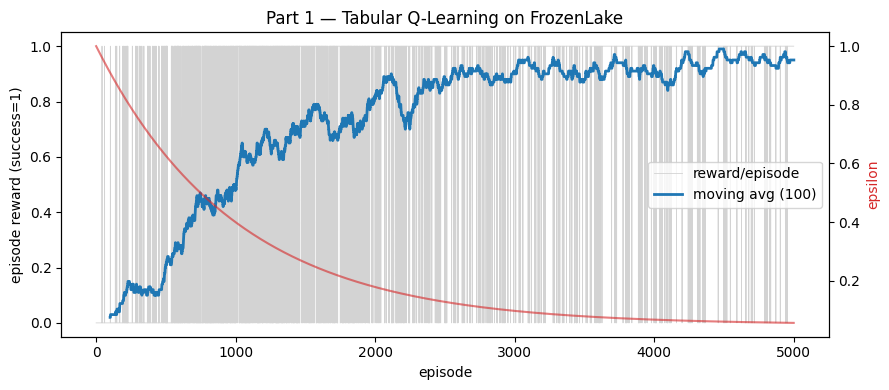

In [8]:
# (1) Learning curve
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(rewards_hist, color="lightgray", linewidth=0.6, label="reward/episode")
ma = moving_average(rewards_hist, window=100)
ax1.plot(np.arange(len(ma)) + 100, ma, color="C0", linewidth=2,
         label="moving avg (100)")
ax1.set_xlabel("episode"); ax1.set_ylabel("episode reward (success=1)")
ax1.set_title("Part 1 — Tabular Q-Learning on FrozenLake")
ax1.legend(loc="center right")
ax2 = ax1.twinx()
ax2.plot(eps_hist, color="C3", alpha=0.6, label="epsilon")
ax2.set_ylabel("epsilon", color="C3")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part1_qlearning", "learning_curve.png"), dpi=120)
plt.show()


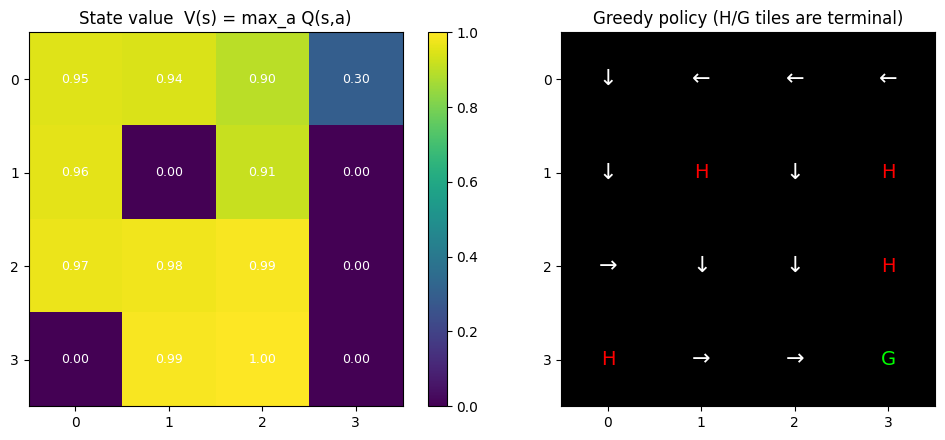

In [9]:
# (2) State-value heatmap and (3) greedy policy arrows.
V = Q_table.max(axis=1).reshape(4, 4)
greedy_actions = Q_table.argmax(axis=1).reshape(4, 4)
desc = env.unwrapped.desc.astype(str)
ARROWS = {0: "←", 1: "↓", 2: "→", 3: "↑"}  # L D R U

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im = axes[0].imshow(V, cmap="viridis")
axes[0].set_title("State value  V(s) = max_a Q(s,a)")
for r in range(4):
    for c in range(4):
        axes[0].text(c, r, f"{V[r,c]:.2f}", ha="center", va="center",
                     color="white", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(np.zeros((4, 4)), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Greedy policy (H/G tiles are terminal)")
for r in range(4):
    for c in range(4):
        tile = desc[r, c]
        if tile in ("H", "G"):
            axes[1].text(c, r, tile, ha="center", va="center",
                         color="red" if tile == "H" else "lime", fontsize=14)
        else:
            axes[1].text(c, r, ARROWS[greedy_actions[r, c]], ha="center",
                         va="center", color="white", fontsize=16)
for ax in axes:
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part1_qlearning", "value_and_policy.png"), dpi=120)
plt.show()


## 1.7 Saving Part 1 results

Save the trained Q-table, reward history, evaluation score, and a human-readable
policy. These files are graded artifacts — do not skip this cell.

In [10]:
p1 = os.path.join(RESULTS_DIR, "part1_qlearning")
np.save(os.path.join(p1, "q_table.npy"), Q_table)
np.save(os.path.join(p1, "rewards_history.npy"), np.asarray(rewards_hist))

with open(os.path.join(p1, "eval_score.json"), "w") as f:
    json.dump({"greedy_success_rate": succ, "greedy_mean_return": mret,
               "n_episodes_trained": len(rewards_hist)}, f, indent=2)

# Human-readable greedy policy grid.
policy_lines = []
for r in range(4):
    row = []
    for c in range(4):
        tile = desc[r, c]
        row.append(tile if tile in ("H", "G", "S") and tile != "S"
                   else ARROWS[greedy_actions[r, c]])
    policy_lines.append(" ".join(row))
policy_text = "\n".join(policy_lines)
with open(os.path.join(p1, "learned_policy.txt"), "w", encoding="utf-8") as f:
    f.write("Greedy policy (arrows = action, H=hole, G=goal):\n" + policy_text + "\n")
print("Saved Part 1 artifacts to", p1)
print(policy_text)


Saved Part 1 artifacts to results\part1_qlearning
↓ ← ← ←
↓ H ↓ H
→ ↓ ↓ H
H → → G


## 1.8 Hyperparameter experiments

Now study how hyperparameters affect learning. The helper below trains a fresh
agent for a given configuration and returns its smoothed learning curve and
greedy success rate.

In [11]:
def run_config(name, **kwargs):
    '''Train one configuration and return (name, rewards_history, success_rate).'''
    slippery = kwargs.pop("is_slippery", False)
    e = gym.make("FrozenLake-v1", is_slippery=slippery)
    Q, rh, _ = train_q_learning(e, log_every=0, **kwargs)
    sr, _ = evaluate_policy(e, Q)
    e.close()
    print(f"  [{name:22s}] greedy success rate = {sr:.3f}")
    return name, rh, sr
# build a list `configs` of at least FOUR experiments that vary the
#       hyperparameters. Suggested ones to compare (pick at least 4):
#         - a baseline:            run_config("baseline", n_episodes=4000)
#         - a small gamma:         gamma=0.5   vs the baseline gamma=0.99
#         - a large learning rate: alpha=0.9   vs a small alpha=0.05
#         - fast vs slow eps_decay: eps_decay=0.01 vs eps_decay=0.0005
#         - the SLIPPERY (stochastic) lake: is_slippery=True
#       Each entry is a call to run_config(name, **hyperparams).
# configs = [
#     run_config("baseline",        n_episodes=4000),
#     ...
# ]

configs = [
    run_config("baseline"),
    run_config("small gamma (gamma=0.5)", gamma=0.5),
    run_config("large learning rate (alpha=0.9)", alpha=0.9),
    run_config("fast decay (eps_decay=0.01)", eps_decay=0.01),
    run_config("slippery lake!", is_slippery=True)
]


  [baseline              ] greedy success rate = 1.000
  [small gamma (gamma=0.5)] greedy success rate = 1.000
  [large learning rate (alpha=0.9)] greedy success rate = 1.000
  [fast decay (eps_decay=0.01)] greedy success rate = 0.000
  [slippery lake!        ] greedy success rate = 0.695


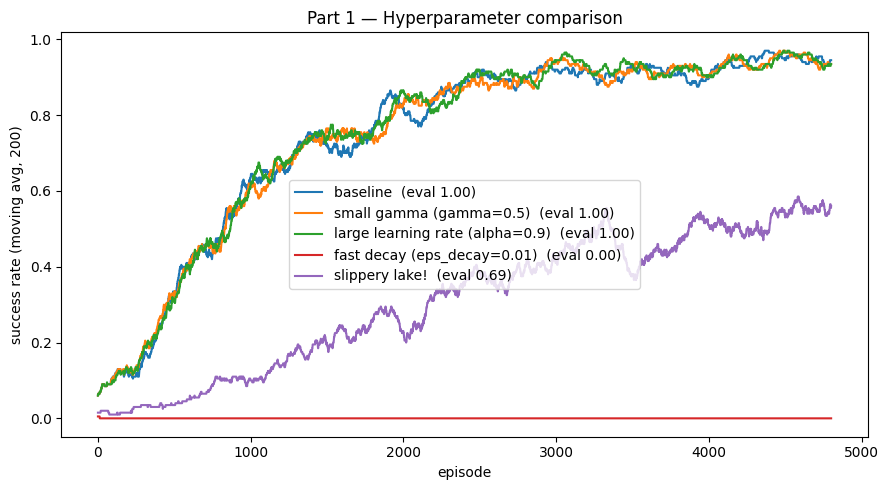

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, rh, sr in configs:
    ma = moving_average(rh, window=200)
    ax.plot(np.arange(len(ma)), ma, label=f"{name}  (eval {sr:.2f})")
ax.set_xlabel("episode"); ax.set_ylabel("success rate (moving avg, 200)")
ax.set_title("Part 1 — Hyperparameter comparison")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part1_qlearning", "hyperparam_comparison.png"), dpi=120)
plt.show()

with open(os.path.join(RESULTS_DIR, "part1_qlearning", "hyperparam_scores.json"), "w") as f:
    json.dump({name: sr for name, _, sr in configs}, f, indent=2)


### ✍️ Written questions — Part 1

Answer in the markdown cell below (2–4 sentences each).

1. **Discounting.** With the sparse `+1`-at-goal reward, explain *why* a smaller
   `γ` encourages the agent to find a **shorter** path. What does `γ = 1` change?
2. **Exploration.** What happens to learning if you set `ε = 0` for the whole run?
   What about `ε = 1`? Relate your answer to the *exploration vs. exploitation*
   trade-off and to **regret**.
3. **Off-policy.** Q-learning is called *off-policy*: it can learn the optimal
   policy even while exploring sub-optimally. Point to the exact term in your
   `q_learning_update` that makes this true.
4. **Slippery lake.** Compare the greedy success rate on the deterministic vs.
   slippery lake. Why does the same algorithm reach a lower success rate when
   transitions are stochastic, even after more episodes?

**Your answers (Part 1):**

1. A smaller γ makes future rewards lose value with every extra step, which forces the agent to take the quickest route to get the highest score. If we set γ = 1, a reward 100 steps away is worth just as much as a reward 1 step away. The agent loses all sense of urgency and doesn't care how long the path takes.

2. Setting ε = 0 means zero exploration, causing the agent to get stuck in early bad habits (like walking into walls) and suffering high regret because it never finds the goal. Setting ε = 1 means pure randomness, meaning the agent jumps around forever and never exploits its learned knowledge to win. We need a balance so the agent can discover the path first and then actually use it to minimize regret.

3. The exact term is `np.max(Q[next_state])`. This specific part updates the Q-table based purely on the absolute best possible move available in the next state. Because it always assumes perfect future play, it completely ignores whatever random action the exploration policy actually ends up choosing.

4. The deterministic lake is highly predictable and hits a perfect 1.000, while the slippery lake drops to 0.695 because random slips accidentally throw the agent into holes. This environmental randomness makes learning much slower and less effective because the algorithm has to spend thousands of extra steps trying to figure out if a failure was a genuinely bad strategic choice or just bad luck.

---
# Part 2 — Deep Q-Learning (DQN) on CartPole

## 2.1 Why the table breaks down

In Part 1 we stored one number per `(state, action)` pair. Lecture warned this
fails when there are *"too many states to visit"* or *"to hold in memory."* The
fix is **Approximate Q-Learning**: represent `Q(s, a)` as a **parameterized
function** and *generalize* across similar states.

In lecture the approximator was **linear** in hand-designed features:
`Q(s,a) = w · f(s,a)`. Here the states are continuous, so instead of inventing
features by hand we let a small **feed-forward neural network** learn them. The
network takes the raw state and outputs one Q-value per action. The learning
signal is the *same* TD target as tabular Q-learning — only the representation
and the update (gradient step instead of table write) change.

## 2.2 The environment: CartPole-v1

A pole is hinged on a cart; the agent pushes the cart left or right to keep the
pole upright and the cart on screen.

| MDP element | In CartPole |
|-------------|-------------|
| **State** `s` | 4 **continuous** numbers: cart position, cart velocity, pole angle, pole angular velocity |
| **Actions** `a` | 2 discrete: `0 = push left`, `1 = push right` |
| **Reward** `R` | `+1` for **every** timestep the pole stays up |
| **Episode** | ends when the pole falls too far, the cart leaves the track, or after 500 steps |
| **Return** | total steps balanced — higher is better; max is 500 |
| **Discount** `γ` | typically `0.99` |

Because reward is `+1` per step, the **episode return = how long the pole stayed
up**. A random agent lasts ~20 steps; a trained DQN should reach the hundreds.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque

torch.manual_seed(GLOBAL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch", torch.__version__, "| device:", DEVICE)

cart_env = gym.make("CartPole-v1")
STATE_DIM = cart_env.observation_space.shape[0]   # 4
N_ACT = cart_env.action_space.n                    # 2
print("state_dim =", STATE_DIM, " n_actions =", N_ACT)


Torch 2.12.0+cpu | device: cpu
state_dim = 4  n_actions = 2


## 2.3 The Q-network

Build a small multilayer perceptron (no convolutions, no recurrence — a plain
feed-forward net). It maps a state vector of length `state_dim` to `n_actions`
Q-values (one per action).

In [14]:
class QNetwork(nn.Module):
    '''Feed-forward network estimating Q(s, .) for every action at once.

    forward(states) takes a tensor of shape (batch, state_dim) and returns a
    tensor of shape (batch, n_actions).
    '''
    def __init__(self, state_dim, n_actions, hidden_size=128):
        super().__init__()
        # define `self.net` as an nn.Sequential MLP:
        #   Linear(state_dim -> hidden_size) -> ReLU
        #   Linear(hidden_size -> hidden_size) -> ReLU
        #   Linear(hidden_size -> n_actions)
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        # return self.net(x)
        return self.net(x)


## 2.4 Experience replay (provided)

A neural network trained on a stream of *consecutive* transitions sees highly
**correlated** data and tends to forget. A **replay buffer** stores past
transitions and we train on **random mini-batches** from it — this de-correlates
updates and reuses experience. We use a *basic uniform* buffer (no prioritization
or other advanced variants). This part is given to you.

In [15]:
class ReplayBuffer:
    '''Fixed-size buffer of (state, action, reward, next_state, done) tuples.'''
    def __init__(self, capacity=50_000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, float(done)))

    def sample(self, batch_size, rng):
        idx = rng.integers(0, len(self.buf), size=batch_size)
        batch = [self.buf[i] for i in idx]
        s, a, r, s2, d = zip(*batch)
        return (torch.as_tensor(np.array(s), dtype=torch.float32, device=DEVICE),
                torch.as_tensor(a, dtype=torch.int64, device=DEVICE),
                torch.as_tensor(r, dtype=torch.float32, device=DEVICE),
                torch.as_tensor(np.array(s2), dtype=torch.float32, device=DEVICE),
                torch.as_tensor(d, dtype=torch.float32, device=DEVICE))

    def __len__(self):
        return len(self.buf)


## 2.5 ε-greedy with a Q-network

Same idea as Part 1, but the greedy action now comes from a **forward pass**
through the network instead of a table lookup.

In [16]:
def select_action(state: np.ndarray, policy_net: QNetwork, epsilon: float, rng: np.random.Generator):
	'''Epsilon-greedy action selection using the Q-network.

	Args:
		state (np.ndarray): current state, shape (state_dim,).
		policy_net (QNetwork): the online network.
		epsilon (float): exploration probability.
		rng (np.random.Generator): random generator.

	Returns:
		action (int).
	'''
	# with probability epsilon, return a random action in [0, N_ACT).
	if rng.random() < epsilon:
		return rng.integers(N_ACT)

	# otherwise, compute Q-values for `state` with a forward pass and
	#       return the greedy action. Wrap the forward pass in torch.no_grad()
	#       and convert the state to a (1, state_dim) float tensor on DEVICE.
	state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
	
	with torch.no_grad():
		q_values = policy_net.forward(state_tensor)

		best_action = q_values.argmax(dim=1).item()

	return best_action

## 2.6 The DQN learning step

This is the Part-2 analogue of `q_learning_update`. For a mini-batch of
transitions we compute, for each one, the **same TD target** as tabular
Q-learning:

$$y = r + \gamma\,\max_{a'} Q_{\text{target}}(s', a')\quad(\text{and } y = r \text{ if } s' \text{ is terminal})$$

then take a gradient step to push the network's prediction `Q(s, a)` toward `y`
(minimizing mean-squared TD error).

**Target network.** We compute the target with a *separate, slowly-updated* copy
of the network (`target_net`). Using the same network to both predict and form
its own target makes training unstable; the frozen copy stabilizes it. We sync
`target_net <- policy_net` every so often. (This is the one extra piece beyond
plain tabular Q-learning; everything else is identical in spirit.)

In [17]:
def dqn_learn_step(policy_net: QNetwork, target_net: QNetwork, optimizer: torch.optim.Optimizer, batch, gamma):
	'''One gradient update on a sampled mini-batch.

	Args:
		policy_net (QNetwork): online network being trained.
		target_net (QNetwork): frozen network used to compute targets.
		optimizer (torch.optim.Optimizer): optimizer over policy_net params.
		batch: tuple (states, actions, rewards, next_states, dones) of tensors,
			shapes (B, state_dim), (B,), (B,), (B, state_dim), (B,).
		gamma (float): discount factor.

	Returns:
		loss_value (float): the scalar loss for logging.
	'''
	states, actions, rewards, next_states, dones = batch
	# (1): current Q estimates for the actions actually taken.
	#   Forward `states` through policy_net -> (B, n_actions), then pick the
	#   column given by `actions`. Hint: .gather(1, actions.unsqueeze(1)).squeeze(1)
	current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

	# (2): the TD target y, using target_net and NO gradient:
	#   with torch.no_grad():
	#       max_next_q = target_net(next_states).max(dim=1).values
	#   y = rewards + gamma * max_next_q * (1 - dones)     # zero future if done
	with torch.no_grad():
		max_next_q = target_net(next_states).max(dim=1).values
		y = rewards + gamma * max_next_q * (1 - dones)

	# (3): loss = mean-squared error between current Q and y
	#   (use F.mse_loss). Then: optimizer.zero_grad(); loss.backward(); optimizer.step()
	loss = F.mse_loss(current_q, y)

	optimizer.zero_grad()
	loss.backward()
	optimizer.step()

	# (4): return loss.item()
	return loss.item()


## 2.7 The DQN training loop

The scaffolding (network/optimizer/buffer creation, ε-decay, target sync,
logging) is provided. You fill in the **per-step interaction**: select an action,
step the env, store the transition, and learn from a mini-batch.

In [18]:
def train_dqn(env, n_episodes=400, gamma=0.99, lr=1e-3, hidden_size=128,
              batch_size=64, buffer_capacity=50_000, warmup=1000,
              target_sync=500, eps_max=1.0, eps_min=0.05, eps_decay=0.005,
              seed=GLOBAL_SEED, log_every=25):
    '''Train a DQN agent on a discrete-action gym env. Returns (policy_net,
    rewards_history, loss_history).'''
    rng = np.random.default_rng(seed)
    state_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy_net = QNetwork(state_dim, n_actions, hidden_size).to(DEVICE)
    target_net = QNetwork(state_dim, n_actions, hidden_size).to(DEVICE)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()
    optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_capacity)

    rewards_history, loss_history = [], []
    global_step = 0

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        epsilon = eps_min + (eps_max - eps_min) * math.exp(-eps_decay * ep)
        total_reward, ep_losses = 0.0, []

        done = False
        while not done:
            # select an action with select_action(state, policy_net, epsilon, rng)
            action = select_action(state, policy_net, epsilon, rng)

            # step the env -> next_state, reward, terminated, truncated, _
            next_state, reward, terminated, truncated, _ = env.step(action)

            # done = terminated or truncated
            done = terminated or truncated

            # store the transition in the buffer. IMPORTANT: store the
            #       `terminated` flag (a real terminal), NOT truncated, so a
            #       time-limit cutoff does not zero the bootstrap target.
            #       buffer.push(state, action, reward, next_state, terminated)
            buffer.push(state, action, reward, next_state, terminated)

            # total_reward += reward ; state = next_state
            total_reward += reward
            state = next_state

            # once len(buffer) >= warmup, sample a batch and call
            #       dqn_learn_step(...); append the returned loss to ep_losses
            if len(buffer) >= warmup:
                batch = buffer.sample(batch_size, rng)
                loss_value = dqn_learn_step(policy_net, target_net, optimizer, batch, gamma)
                ep_losses.append(loss_value)

            global_step += 1
            if global_step % target_sync == 0:
                target_net.load_state_dict(policy_net.state_dict())

        rewards_history.append(total_reward)
        loss_history.append(np.mean(ep_losses) if ep_losses else 0.0)
        if log_every and (ep + 1) % log_every == 0:
            recent = np.mean(rewards_history[-log_every:])
            print(f"  episode {ep+1:4d} | epsilon {epsilon:.3f} | "
                  f"avg return (last {log_every}) {recent:6.1f}")

    return policy_net, rewards_history, loss_history


In [19]:
# Train the DQN. Expect noisy returns that trend upward into the hundreds.
policy_net, dqn_rewards, dqn_losses = train_dqn(cart_env, n_episodes=400)
print("\nTraining finished. Episodes:", len(dqn_rewards),
      "| best episode return:", max(dqn_rewards))


  episode   25 | epsilon 0.893 | avg return (last 25)   23.2
  episode   50 | epsilon 0.794 | avg return (last 25)   19.8
  episode   75 | epsilon 0.706 | avg return (last 25)   20.7
  episode  100 | epsilon 0.629 | avg return (last 25)   20.4
  episode  125 | epsilon 0.561 | avg return (last 25)   38.0
  episode  150 | epsilon 0.501 | avg return (last 25)   50.0
  episode  175 | epsilon 0.448 | avg return (last 25)  101.9
  episode  200 | epsilon 0.401 | avg return (last 25)   60.2
  episode  225 | epsilon 0.360 | avg return (last 25)   67.2
  episode  250 | epsilon 0.324 | avg return (last 25)  116.1
  episode  275 | epsilon 0.291 | avg return (last 25)   86.2
  episode  300 | epsilon 0.263 | avg return (last 25)  103.5
  episode  325 | epsilon 0.238 | avg return (last 25)  170.4
  episode  350 | epsilon 0.216 | avg return (last 25)  119.2
  episode  375 | epsilon 0.196 | avg return (last 25)   88.0
  episode  400 | epsilon 0.179 | avg return (last 25)   72.2

Training finished. Epis

## 2.8 Learning curve

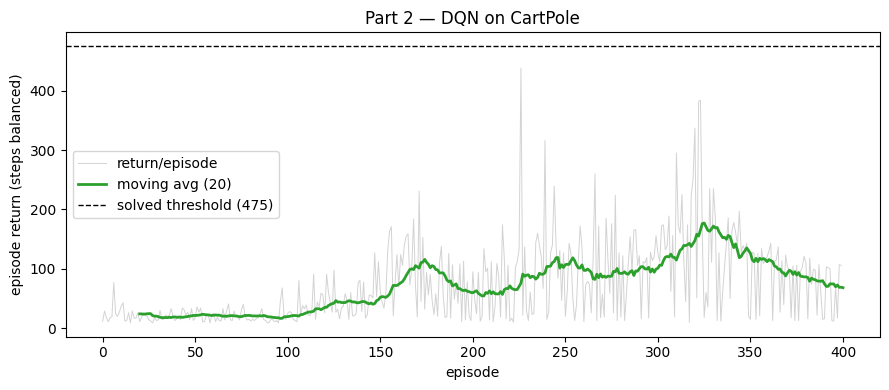

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dqn_rewards, color="lightgray", linewidth=0.7, label="return/episode")
ma = moving_average(dqn_rewards, window=20)
ax.plot(np.arange(len(ma)) + 20, ma, color="C2", linewidth=2, label="moving avg (20)")
# dynamically find the max steps of the current environment
max_possible_steps = cart_env.spec.max_episode_steps if env.spec else 500
solved_threshold = int(0.95 * max_possible_steps)
ax.axhline(solved_threshold, color="k", linestyle="--", linewidth=1, label=f"solved threshold ({solved_threshold})")
ax.set_xlabel("episode"); ax.set_ylabel("episode return (steps balanced)")
ax.set_title("Part 2 — DQN on CartPole")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part2_dqn", "learning_curve.png"), dpi=120)
plt.show()


## 2.9 Evaluating the greedy policy

In [21]:
def evaluate_dqn(env, policy_net, n_episodes=30, seed=999):
    '''Run the greedy (epsilon=0) policy. Returns (mean_return, std_return).'''
    rng = np.random.default_rng(seed)
    returns = []
    # for each evaluation episode, run the GREEDY policy
    #       (call select_action with epsilon=0.0) until the episode ends,
    #       summing reward; append each episode's total to `returns`.
    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        ep_reward = 0.0
        done = False
        
        while not done:
            action = select_action(state, policy_net, epsilon=0.0, rng=rng)

            next_state, reward, terminated, truncated, _ = env.step(action)
            
            ep_reward += reward
            state = next_state
            done = terminated or truncated
            
        returns.append(ep_reward)

    returns = np.asarray(returns)
    return float(returns.mean()), float(returns.std())

mean_ret, std_ret = evaluate_dqn(cart_env, policy_net)
print(f"Greedy evaluation over 30 episodes: {mean_ret:.1f} +/- {std_ret:.1f}")


Greedy evaluation over 30 episodes: 112.7 +/- 3.3


## 2.10 Saving Part 2 results

In [22]:
p2 = os.path.join(RESULTS_DIR, "part2_dqn")
torch.save(policy_net.state_dict(), os.path.join(p2, "dqn_weights.pt"))
np.save(os.path.join(p2, "rewards_history.npy"), np.asarray(dqn_rewards))
np.save(os.path.join(p2, "loss_history.npy"), np.asarray(dqn_losses))
with open(os.path.join(p2, "eval_score.json"), "w") as f:
    json.dump({"greedy_mean_return": mean_ret, "greedy_std_return": std_ret,
               "n_episodes_trained": len(dqn_rewards),
               "best_train_return": float(max(dqn_rewards))}, f, indent=2)
print("Saved Part 2 artifacts to", p2)


Saved Part 2 artifacts to results\part2_dqn


## 2.11 Hyperparameter experiment (DQN)

Pick **one** hyperparameter and study its effect by training (at least) two
additional configurations and comparing their learning curves to the baseline.

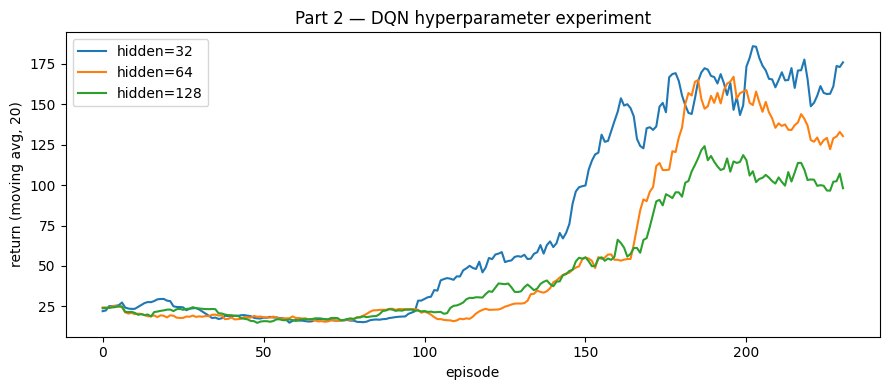

In [23]:
# choose ONE hyperparameter to vary (e.g. hidden_size, lr, gamma, or
#       eps_decay) and train at least two more configs. Keep n_episodes modest
#       (e.g. 250) so this runs in reasonable time. Store results as a list of
#       (label, rewards_history) and plot their moving averages together.
#
# Example skeleton:
# dqn_experiments = []
# for hs in [32, 128]:
#     _, rh, _ = train_dqn(gym.make("CartPole-v1"), n_episodes=250,
#                          hidden_size=hs, log_every=0)
#     dqn_experiments.append((f"hidden={hs}", rh))

dqn_experiments = []
for hs in [32, 64, 128]:
	_, rh, _ = train_dqn(gym.make("CartPole-v1"), n_episodes=250, hidden_size=hs, log_every=0)
	dqn_experiments.append((f"hidden={hs}", rh))

fig, ax = plt.subplots(figsize=(9, 4))
for label, rh in dqn_experiments:
	ma = moving_average(rh, window=20)
	ax.plot(np.arange(len(ma)), ma, label=label)
ax.set_xlabel("episode"); ax.set_ylabel("return (moving avg, 20)")
ax.set_title("Part 2 — DQN hyperparameter experiment")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part2_dqn", "hyperparam_comparison.png"), dpi=120)
plt.show()


Running hidden_size experiments...
Running gamma experiments...
Running buffer_capacity experiments...


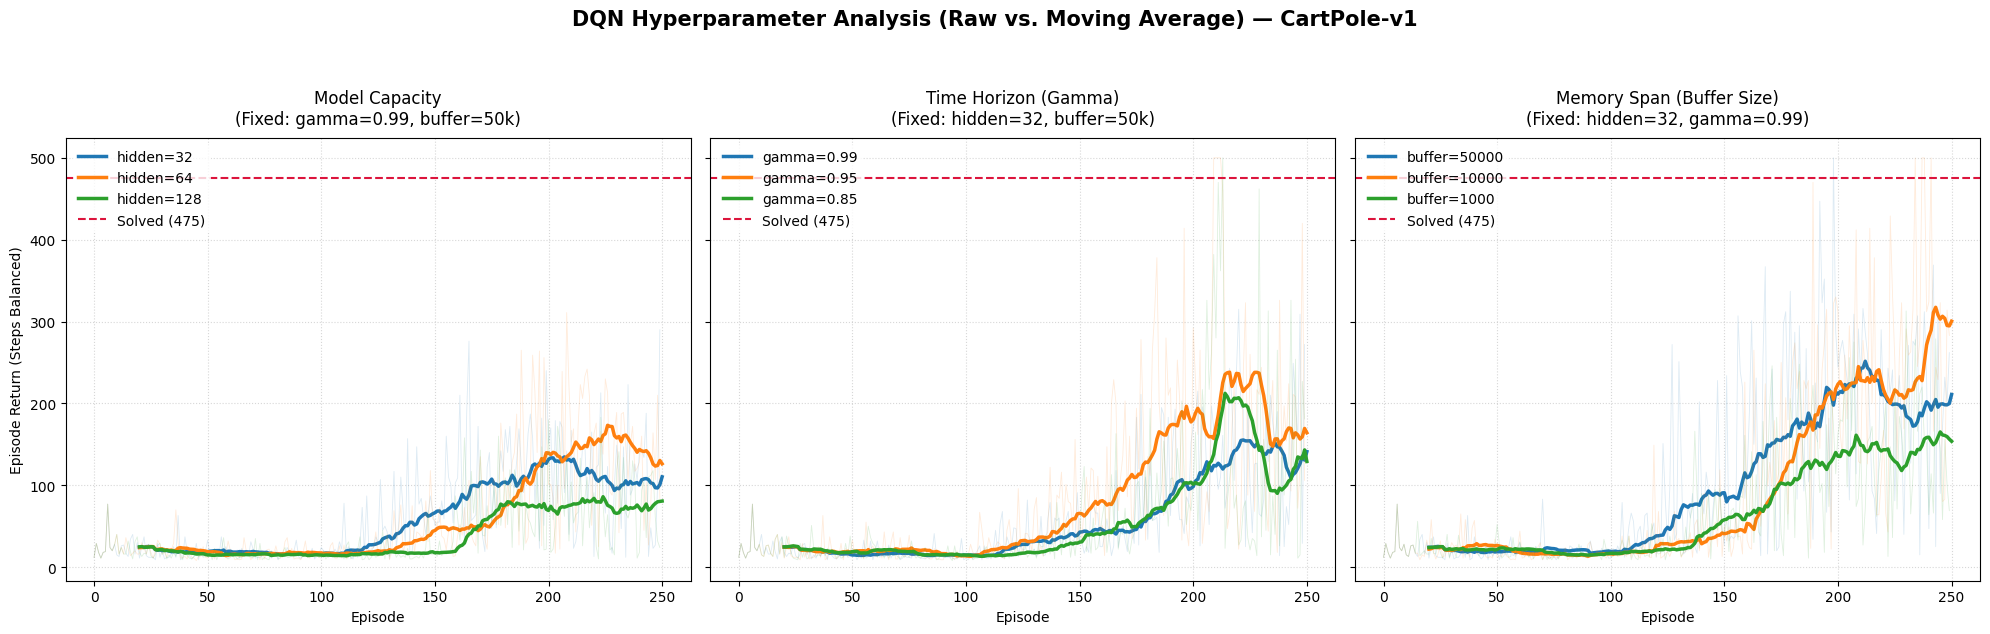

In [24]:
n_episodes = 250
window_size = 20

results = {
    "hidden_size": [],
    "gamma": [],
    "buffer_capacity": []
}

# --- Experiment 1: Hidden Size Sweeping ---
print("Running hidden_size experiments...")
for hs in [32, 64, 128]:
    _, rh, _ = train_dqn(gym.make("CartPole-v1"), n_episodes=n_episodes, hidden_size=hs, log_every=0)
    results["hidden_size"].append((f"hidden={hs}", rh))

# --- Experiment 2: Gamma Sweeping (Using our best hidden_size=32) ---
print("Running gamma experiments...")
for g in [0.99, 0.95, 0.85]:
    _, rh, _ = train_dqn(gym.make("CartPole-v1"), n_episodes=n_episodes, hidden_size=32, gamma=g, log_every=0)
    results["gamma"].append((f"gamma={g}", rh))

# --- Experiment 3: Buffer Capacity Sweeping (Using hidden_size=32, gamma=0.99) ---
print("Running buffer_capacity experiments...")
for bc in [50000, 10000, 1000]:
    _, rh, _ = train_dqn(gym.make("CartPole-v1"), n_episodes=n_episodes, hidden_size=32, buffer_capacity=bc, log_every=0)
    results["buffer_capacity"].append((f"buffer={bc}", rh))

# Plotting the 1x3 Side-by-Side Grid Dashboard
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

categories = ["hidden_size", "gamma", "buffer_capacity"]
titles = [
    "Model Capacity\n(Fixed: gamma=0.99, buffer=50k)",
    "Time Horizon (Gamma)\n(Fixed: hidden=32, buffer=50k)",
    "Memory Span (Buffer Size)\n(Fixed: hidden=32, gamma=0.99)"
]

for i, cat in enumerate(categories):
    ax = axes[i]
    
    # Plot both raw and moving averages for each configuration
    for label, rh in results[cat]:
        # Calculate moving average
        ma = moving_average(rh, window=window_size)
        
        # 1. Plot the raw "barcode" returns in the background first
        # We capture the line plot object 'p' to borrow its color
        p = ax.plot(np.arange(len(rh)), rh, alpha=0.15, linewidth=0.6)
        line_color = p[0].get_color()
        
        # 2. Plot the smoothed moving average on top, matching the color perfectly
        ax.plot(np.arange(len(ma)) + window_size, ma, linewidth=2.5, color=line_color, label=label)
    
    # Draw the objective ceiling line across all subplots
    ax.axhline(solved_threshold, color="crimson", linestyle="--", linewidth=1.5, label=f"Solved ({solved_threshold})")
    
    ax.set_xlabel("Episode")
    ax.set_title(titles[i], fontsize=12, pad=10)
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
    ax.grid(True, linestyle=":", alpha=0.5)

# Style adjustments for clarity across the dashboard
axes[0].set_ylabel(f"Episode Return (Steps Balanced)")
fig.suptitle("DQN Hyperparameter Analysis (Raw vs. Moving Average) — CartPole-v1", fontsize=15, fontweight="bold", y=1.05)
fig.tight_layout()

# Save the newly detailed dashboard figure
os.makedirs(os.path.join(RESULTS_DIR, "part2_dqn"), exist_ok=True)
fig.savefig(os.path.join(RESULTS_DIR, "part2_dqn", "comprehensive_hyperparam_with_raw.png"), dpi=120, bbox_inches="tight")
plt.show()

Training the Champion Model for 750 episodes...
Config: hidden=32, gamma=0.99, buffer=50000


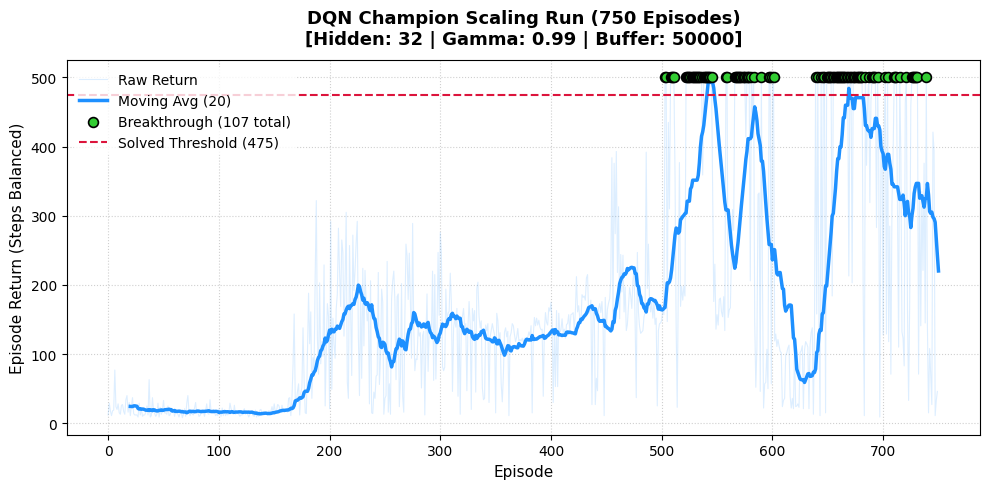

In [29]:
# --- Champion Configuration ---
n_episodes = 750  # give it more number of episodes to try
window_size = 20
solved_threshold = 475

# our champion hyperparameters
champion_hs = 32
champion_gamma = 0.99
champion_buffer = 50000

print(f"Training the Champion Model for {n_episodes} episodes...")
print(f"Config: hidden={champion_hs}, gamma={champion_gamma}, buffer={champion_buffer}")

_, champion_rh, _ = train_dqn(
    gym.make("CartPole-v1"), 
    n_episodes=n_episodes, 
    hidden_size=champion_hs, 
    gamma=champion_gamma, 
    buffer_capacity=champion_buffer, 
    log_every=0
)

# --- Plotting the Champion's Journey ---
fig, ax = plt.subplots(figsize=(10, 5))

rh_array = np.asarray(champion_rh)
ma = moving_average(champion_rh, window=window_size)

# 1. Plot the raw barcode returns
ax.plot(np.arange(len(champion_rh)), champion_rh, alpha=0.15, color='dodgerblue', linewidth=0.8, label="Raw Return")

# 2. Plot the smoothed moving average
ax.plot(np.arange(len(ma)) + window_size, ma, color='dodgerblue', linewidth=2.5, label="Moving Avg (20)")

# 3. Bold and highlight EVERY breakthrough episode
breakthrough_episodes = np.where(rh_array >= solved_threshold)[0]
if len(breakthrough_episodes) > 0:
    ax.scatter(breakthrough_episodes, rh_array[breakthrough_episodes], 
               color='limegreen', alpha=1.0, s=50, marker='o', 
               edgecolors='black', linewidth=1.2, zorder=5, label=f"Breakthrough ({len(breakthrough_episodes)} total)")

# 4. Draw the solved target line
ax.axhline(solved_threshold, color="crimson", linestyle="--", linewidth=1.5, label=f"Solved Threshold ({solved_threshold})")

# Formatting updates for a clean standalone view
ax.set_xlabel("Episode", fontsize=11)
ax.set_ylabel("Episode Return (Steps Balanced)", fontsize=11)
ax.set_title(f"DQN Champion Scaling Run ({n_episodes} Episodes)\n[Hidden: {champion_hs} | Gamma: {champion_gamma} | Buffer: {champion_buffer}]", fontsize=13, fontweight='bold', pad=12)
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

# Save champion plot
os.makedirs(os.path.join(RESULTS_DIR, "part2_dqn"), exist_ok=True)
fig.savefig(os.path.join(RESULTS_DIR, "part2_dqn", "champion_500_episodes.png"), dpi=120, bbox_inches="tight")
plt.show()

---
## 2. Wrap-up reflection

1. Both parts are **model-free**: the agent never learned `T(s,a,s')` or
   `R(s,a,s')`. In one short paragraph, explain how each agent nonetheless ended
   up acting near-optimally.
2. Q-learning is **off-policy**. Why is that a desirable property for an agent
   that must *explore* while it learns?
3. Give one concrete situation where tabular Q-learning is the right tool, and
   one where you would reach for DQN instead.

**Your answers (Part 3):**

1. Model-free agents don't need a map of the world because they learn directly from experience. By trying random actions and updating their Q-values based on the immediate rewards they receive, they naturally discover the best paths through pure trial and error.

2. It is desirable because the agent can take sub-optimal, random, or risky actions to discover the environment (explore) without ruining its ability to calculate and learn the true optimal policy.

3.  * Tabular Q-Learning: Best for small, simple games like Tic-Tac-Toe or a 10x10 maze, where every single possible state easily fits into a standard lookup table.

	* DQN: Best for massive, complex tasks like a self-driving car or Atari games, where the possibilities are infinite and we need a neural network to generalize and guess the best move.

---
### Submission checklist
- [ ] All `# TODO` cells implemented; notebook runs top-to-bottom with no errors.
- [ ] All written-answer cells filled in.
- [ ] `results/` folder contains the saved Q-table, model weights, reward
      histories, evaluation scores, plots, and the learned policy.
